# Compute Fused Dissimilarity Matrix
Compute geodesic angle-delay profile (ADP) dissimilarity matrix.

## Imports

In [1]:
from dataset_RT import training_set
import multiprocessing as mp
import scipy.sparse.csgraph
import sklearn.neighbors
import tensorflow as tf
import scipy.spatial
import numpy as np
import tqdm
import matplotlib.pyplot as plt

2026-02-09 12:59:33.994030: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770641974.016354    6717 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770641974.023386    6717 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770641974.041150    6717 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770641974.041167    6717 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770641974.041169    6717 computation_placer.cc:177] computation placer alr

## Load Dataset

In [2]:
def csi_time_domain(csi, pos):
    csi = tf.signal.fftshift(tf.signal.ifft(tf.signal.fftshift(csi, axes = -1)), axes=-1)
    return csi, pos

def cut_out_taps(tap_start, tap_stop):
    def cut_out_taps_func(csi, pos):
        return csi[...,tap_start:tap_stop], pos
    return cut_out_taps_func


training_set = training_set.map(csi_time_domain, num_parallel_calls = tf.data.AUTOTUNE)
training_set = training_set.map(cut_out_taps(27, 40), num_parallel_calls = tf.data.AUTOTUNE)

### Load classical position estimates

In [3]:
classical_positions = np.load("results/classical_positions.npy")

### From TensorFlow to NumPy

In [4]:
groundtruth_positions = []
csi_time_domain = []

for csi, pos in training_set.prefetch(tf.data.AUTOTUNE).batch(1000):
    csi_time_domain.append(csi.numpy())
    groundtruth_positions.append(pos.numpy())

csi_time_domain = np.concatenate(csi_time_domain)
groundtruth_positions = np.concatenate(groundtruth_positions)

2026-02-09 12:59:37.615051: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-02-09 12:59:38.580439: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Dissimilarity Metrics and Dissimilarity Matrix Computation

### Step 1: ADP-based dissimilarity matrix

In [5]:
adp_dissimilarity_matrix = np.zeros((csi_time_domain.shape[0], csi_time_domain.shape[0]), dtype=np.float32)

def adp_dissimilarities_worker(todo_queue, output_queue):
    def adp_dissimilarities(index):
        # h has shape (arrays, antenna rows, antenna columns, taps), w has shape (datapoints, arrays, antenna rows, antenna columns, taps)
        h = csi_time_domain[index]
        w = csi_time_domain[index:]

        dotproducts = np.abs(np.einsum("brmt,lbrmt->lbt", np.conj(h), w))**2
        norms = np.real(np.einsum("brmt,brmt->bt", h, np.conj(h)) * np.einsum("lbrmt,lbrmt->lbt", w, np.conj(w)))
        
        return np.sum(1 - dotproducts / norms, axis = (1, 2))

    while True:
        index = todo_queue.get()

        if index == -1:
            output_queue.put((-1, None))
            break
        
        output_queue.put((index, adp_dissimilarities(index)))

with tqdm.tqdm(total = csi_time_domain.shape[0]**2) as bar:
    todo_queue = mp.Queue()
    output_queue = mp.Queue()

    for i in range(csi_time_domain.shape[0]):
        todo_queue.put(i)
    
    for i in range(mp.cpu_count()):
        todo_queue.put(-1)
        p = mp.Process(target = adp_dissimilarities_worker, args = (todo_queue, output_queue))
        p.start()

    finished_processes = 0
    while finished_processes != mp.cpu_count():
        i, d = output_queue.get()

        if i == -1:
            finished_processes = finished_processes + 1
        else:
            adp_dissimilarity_matrix[i,i:] = d
            adp_dissimilarity_matrix[i:,i] = d
            bar.update(2 * len(d) - 1)

100%|██████████| 25000000/25000000 [01:10<00:00, 355903.86it/s]


### Step 2: Geodesic Dissimilarity Matrix

In [6]:
n_neighbors = 20

nbrs_alg = sklearn.neighbors.NearestNeighbors(n_neighbors = n_neighbors, metric="precomputed", n_jobs = -1)
nbrs = nbrs_alg.fit(adp_dissimilarity_matrix)
nbg = sklearn.neighbors.kneighbors_graph(nbrs, n_neighbors, metric = "precomputed", mode="distance")

In [7]:
dissimilarity_matrix_geodesic = np.zeros((nbg.shape[0], nbg.shape[1]), dtype = np.float32)

def shortest_path_worker(todo_queue, output_queue):
    while True:
        index = todo_queue.get()

        if index == -1:
            output_queue.put((-1, None))
            break

        d = scipy.sparse.csgraph.dijkstra(nbg, directed=False, indices=index)
        output_queue.put((index, d))

with tqdm.tqdm(total = nbg.shape[0]**2) as bar:
    todo_queue = mp.Queue()
    output_queue = mp.Queue()

    for i in range(nbg.shape[0]):
        todo_queue.put(i)
    
    for i in range(mp.cpu_count()):
        todo_queue.put(-1)
        p = mp.Process(target = shortest_path_worker, args = (todo_queue, output_queue))
        p.start()

    finished_processes = 0
    while finished_processes != mp.cpu_count():
        i, d = output_queue.get()

        if i == -1:
            finished_processes = finished_processes + 1
        else:
            dissimilarity_matrix_geodesic[i,:] = d
            bar.update(len(d))

100%|██████████| 25000000/25000000 [00:03<00:00, 7392117.45it/s] 


## Save Dissimilarity Matrix as NumPy

In [8]:
np.save("results/dissimilarity_matrix_geodesic.npy", dissimilarity_matrix_geodesic)

## Scaling the Dissilimarity Matrix
All values should be in meters...

In [9]:
scaling_nth_reduction = 30
classical_positions_reduced = classical_positions[::scaling_nth_reduction]
dissimilarity_matrix_reduced = dissimilarity_matrix_geodesic[::scaling_nth_reduction, ::scaling_nth_reduction]
classical_distance_matrix = scipy.spatial.distance_matrix(classical_positions_reduced, classical_positions_reduced)

In [10]:
dissimilarity_unit_meters = np.full_like(dissimilarity_matrix_reduced, np.nan)
diff = np.divide(dissimilarity_matrix_reduced, classical_distance_matrix, out = dissimilarity_unit_meters, where = classical_distance_matrix != 0)
dissimilarity_unit_meters = dissimilarity_unit_meters.flatten()
scaling_factor_meters = np.median(dissimilarity_unit_meters[np.isfinite(dissimilarity_unit_meters)])

In [11]:
dissimilarity_matrix_geodesic_meters = dissimilarity_matrix_geodesic / scaling_factor_meters

## Save Scaled Dissimilarity Matrix

In [12]:
np.save("results/dissimilarity_matrix_geodesic_meters.npy", dissimilarity_matrix_geodesic_meters)

## Optional: Visualize Dissilimarity Matrix

In [13]:
# Compute distances between groundtruth positions
groundtruth_distance_matrix = scipy.spatial.distance_matrix(groundtruth_positions, groundtruth_positions)

In [14]:
def plot_dissimilarity_over_euclidean_distance(dissimilarity_matrix, distance_matrix, label = None):
    nth_reduction = 1
    dissimilarities_flat = dissimilarity_matrix[::nth_reduction, ::nth_reduction].flatten()
    distances_flat = distance_matrix[::nth_reduction, ::nth_reduction].flatten()
    
    max_distance = np.max(distances_flat)
    bins = np.linspace(0, max_distance, 200)
    bin_indices = np.digitize(distances_flat, bins)
    
    bin_medians = np.zeros(len(bins) - 1)
    bin_25_perc = np.zeros(len(bins) - 1)
    bin_75_perc = np.zeros(len(bins) - 1)
    for i in range(1, len(bins)):
        bin_values = dissimilarities_flat[bin_indices == i]
        if len(bin_values) > 0:
            bin_25_perc[i - 1], bin_medians[i - 1], bin_75_perc[i - 1] = np.percentile(bin_values, [25, 50, 75])
    
    plt.plot(bins[:-1], bin_medians, label = label)
    plt.fill_between(bins[:-1], bin_25_perc, bin_75_perc, alpha=0.5)

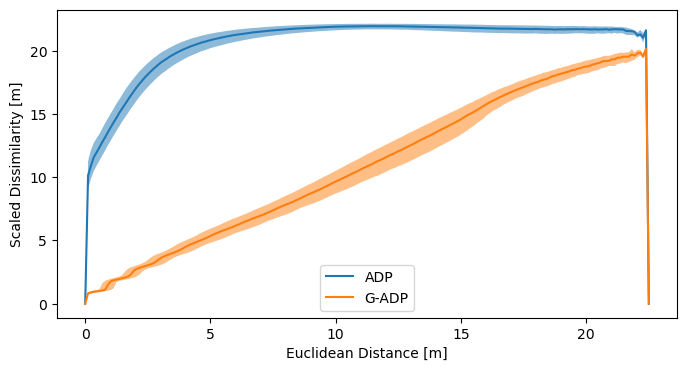

In [15]:
plt.figure(figsize=(8,4))

sc_f = np.max(groundtruth_distance_matrix) / np.max(adp_dissimilarity_matrix)

plot_dissimilarity_over_euclidean_distance(sc_f * adp_dissimilarity_matrix, groundtruth_distance_matrix, "ADP")
plot_dissimilarity_over_euclidean_distance(dissimilarity_matrix_geodesic_meters, groundtruth_distance_matrix, "G-ADP")

plt.legend()
plt.xlabel("Euclidean Distance [m]")
plt.ylabel("Scaled Dissimilarity [m]")
plt.show()